# Kapsamlı Gürültü Giderme Değerlendirmesi

Bu notebook, tuz-biber (salt & pepper) gürültüsü giderme yöntemlerini literatürdeki **tüm geçerli metriklerle** karşılaştırır.

## Metrikler

### 1. Görüntü Kalitesi Metrikleri (Image Quality Assessment)
| Metrik | Birim | Yön | Kaynak |
|--------|-------|-----|--------|
| **PSNR** | dB | ↑ | Evrensel standart (IEEE TIP, CVPR) |
| **SSIM** | [0,1] | ↑ | Wang et al., TIP 2004 |
| **MAE** | piksel (0-255) | ↓ | Yaygın kullanım |
| **RMSE** | piksel (0-255) | ↓ | MSE'nin kök versiyonu |

### 2. Gürültü Restorasyon Metrikleri (Noise Restoration Quality)
Bozulan piksellerin ne kadar doğru restore edildiği — **piksel düzeyinde F1/Precision/Recall**:
- **TP**: Bozuk piksel → doğru restore edildi
- **FP**: Temiz piksel → yanlışlıkla değiştirildi (over-smoothing)
- **FN**: Bozuk piksel → düzeltilemedi
- **TN**: Temiz piksel → korundu

### 3. Semantik Koruma Metriği (Downstream Task)
- **ResNet-18 Top-1 Acc.**: Temizlenmiş görüntünün, orijinal temiz görüntüyle aynı ImageNet sınıfını üretme oranı.
  Semantik içeriğin ne kadar korunduğunu ölçer.

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

warnings.filterwarnings('ignore')

ROOT = os.path.dirname(os.path.abspath('__file__'))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_LEVELS = [10, 30, 50, 70, 90]

print(f'Cihaz: {DEVICE}')
print(f'Çalışma dizini: {ROOT}')

Cihaz: cuda
Çalışma dizini: /home/mustafa/Projeler/noise-test


In [2]:
METHODS = {
    'Noisy'      : 'Tiny-Imagenet/Tiny_Noisy_{}',
    'SMF'        : 'Tiny-Imagenet/Tiny_Cleaned_SMF_{}',
    'AMF'        : 'Tiny-Imagenet/Tiny_Cleaned_AMF_{}',
    'MDBUTMF'    : 'Tiny-Imagenet/Tiny_Cleaned_MDBUTMF_{}',
    'EMPR'       : 'Tiny-Imagenet/Tiny_Cleaned_EMPR_{}',
    'HDMR'       : 'Tiny-Imagenet/Tiny_Cleaned_HDMR_{}',
    'DnCNN'      : 'Tiny-Imagenet/Tiny_Cleaned_DnCNN_{}',
    'DnCNN-SP'   : 'Tiny-Imagenet/Tiny_Cleaned_DnCNN_SP_{}',
    'DAMF'       : 'Tiny-Imagenet/Tiny_Cleaned_DAMF_{}',
    'SeConvUNet' : 'Tiny-Imagenet/Tiny_Cleaned_SeConvUNet_{}',
}

ORIG_FOLDER = 'Tiny-Imagenet/Tiny_Orijinal'

In [3]:
# ─────────────────────────────────────────────────────────
# 1. Temiz orijinal görüntüleri yükle (ground truth)
# ─────────────────────────────────────────────────────────

def load_originals(folder: str) -> dict:
    """stem -> np.ndarray (H,W,3) uint8, RGB"""
    orig = {}
    for ext in ('*.JPEG', '*.jpg', '*.png'):
        for p in glob.glob(os.path.join(folder, ext)):
            stem = os.path.splitext(os.path.basename(p))[0]
            img = np.array(Image.open(p).convert('RGB'))
            orig[stem] = img
    return orig

print('Orijinal görüntüler yükleniyor...')
originals = load_originals(ORIG_FOLDER)
print(f'{len(originals)} görüntü yüklendi.')

Orijinal görüntüler yükleniyor...
1000 görüntü yüklendi.


In [4]:
# ─────────────────────────────────────────────────────────
# 2. Görüntü kalitesi fonksiyonları
# ─────────────────────────────────────────────────────────

def compute_psnr(img1: np.ndarray, img2: np.ndarray) -> float:
    """PSNR (dB), data_range=255."""
    return peak_signal_noise_ratio(img1, img2, data_range=255)

def compute_ssim(img1: np.ndarray, img2: np.ndarray) -> float:
    """Multichannel SSIM (RGB). channel_axis=-1 skimage>=0.19."""
    return structural_similarity(img1, img2, data_range=255, channel_axis=-1)

def compute_mae(img1: np.ndarray, img2: np.ndarray) -> float:
    return float(np.mean(np.abs(img1.astype(np.float64) - img2.astype(np.float64))))

def compute_rmse(img1: np.ndarray, img2: np.ndarray) -> float:
    return float(np.sqrt(np.mean((img1.astype(np.float64) - img2.astype(np.float64))**2)))

In [5]:
# ─────────────────────────────────────────────────────────
# 3. Piksel düzeyinde F1 / Precision / Recall
#
# Gürültü maskesi: S&P gürültüsü pikseli tam siyah (0,0,0)
# veya tam beyaz (255,255,255) yapar. Bu nedenle:
#   noise_pixel  = (tüm kanallar 0) VEYA (tüm kanallar 255)
#                  VE orijinalden herhangi bir kanalda >30 fark var.
#
# Restore edilmiş piksel: Tüm kanallarda orijinalden ≤10 fark var.
# ─────────────────────────────────────────────────────────

DETECT_THR   = 30   # gürültü pikselini tanımlama eşiği
RESTORE_THR  = 10   # başarılı restorasyon eşiği

def sp_noise_mask(noisy: np.ndarray, clean: np.ndarray) -> np.ndarray:
    """Boolean mask: True=bozuk piksel."""
    is_extreme = np.all(noisy == 0, axis=2) | np.all(noisy == 255, axis=2)
    diff_any   = np.any(np.abs(noisy.astype(np.int32) - clean.astype(np.int32)) > DETECT_THR, axis=2)
    return is_extreme & diff_any

def compute_f1_metrics(denoised: np.ndarray, clean: np.ndarray, noise_mask: np.ndarray):
    """Piksel düzeyinde TP/FP/FN/TN ve türetilen Precision/Recall/F1."""
    restored = np.all(
        np.abs(denoised.astype(np.int32) - clean.astype(np.int32)) <= RESTORE_THR,
        axis=2
    )
    TP = int(np.sum( noise_mask &  restored))   # bozuk → doğru düzeltildi
    FP = int(np.sum(~noise_mask & ~restored))   # temiz → yanlış değiştirildi
    FN = int(np.sum( noise_mask & ~restored))   # bozuk → düzeltilemedi
    TN = int(np.sum(~noise_mask &  restored))   # temiz → korundu

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

In [6]:
# ─────────────────────────────────────────────────────────
# 4. ResNet-18 sınıflandırma modeli
# ─────────────────────────────────────────────────────────

print('ResNet-18 yükleniyor...')
clf_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)
clf_model.eval()

clf_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def predict_class(img_np: np.ndarray) -> int:
    pil = Image.fromarray(img_np)
    t   = clf_transform(pil).unsqueeze(0).to(DEVICE)
    return clf_model(t).argmax(1).item()

print('Orijinal görüntüler için referans sınıf tahminleri hesaplanıyor...')
baseline_cls = {stem: predict_class(img) for stem, img in tqdm(originals.items(), desc='Baseline')}
print(f'{len(baseline_cls)} referans tahmin hazır.')

ResNet-18 yükleniyor...
Orijinal görüntüler için referans sınıf tahminleri hesaplanıyor...


Baseline: 100%|██████████| 1000/1000 [00:03<00:00, 256.99it/s]

1000 referans tahmin hazır.


In [7]:
# ─────────────────────────────────────────────────────────
# 5. ANA DÖNGÜ: Tüm yöntemler × tüm seviyeler
# ─────────────────────────────────────────────────────────

# Sonuç yapısı: records[method][level] = {psnr, ssim, mae, rmse, prec, rec, f1, acc}
records = {m: {lv: None for lv in NOISE_LEVELS} for m in METHODS}

for method, tmpl in METHODS.items():
    print(f'\n═══ {method} ═══')
    for level in NOISE_LEVELS:
        folder     = os.path.join(ROOT, tmpl.format(level))
        noisy_dir  = os.path.join(ROOT, f'Tiny-Imagenet/Tiny_Noisy_{level}')

        if not os.path.isdir(folder):
            print(f'  %{level}: Klasör bulunamadı → atlanıyor ({folder})')
            continue

        img_paths = sorted(glob.glob(os.path.join(folder, '*.png')))
        if len(img_paths) == 0:
            print(f'  %{level}: Klasörde görüntü yok → atlanıyor')
            continue

        psnr_list, ssim_list, mae_list, rmse_list = [], [], [], []
        prec_list, rec_list, f1_list, acc_list    = [], [], [], []

        for img_path in tqdm(img_paths, desc=f'  %{level}', leave=False):
            stem = os.path.splitext(os.path.basename(img_path))[0]
            if stem not in originals:
                continue

            clean    = originals[stem]                      # (H,W,3) uint8
            denoised = np.array(Image.open(img_path).convert('RGB'))

            # Boyut uyumsuzluğu varsa yeniden boyutlandır (güvenlik)
            if denoised.shape != clean.shape:
                denoised = np.array(
                    Image.fromarray(denoised).resize(
                        (clean.shape[1], clean.shape[0]), Image.BILINEAR
                    )
                )

            # ── Görüntü kalite metrikleri ──
            psnr_list.append(compute_psnr(clean, denoised))
            ssim_list.append(compute_ssim(clean, denoised))
            mae_list.append(compute_mae(clean, denoised))
            rmse_list.append(compute_rmse(clean, denoised))

            # ── F1 için gürültü maskesi (noisy görüntüden türet) ──
            noisy_path = os.path.join(noisy_dir, stem + '.png')
            if os.path.exists(noisy_path):
                noisy = np.array(Image.open(noisy_path).convert('RGB'))
                nmask = sp_noise_mask(noisy, clean)
                p, r, f = compute_f1_metrics(denoised, clean, nmask)
                prec_list.append(p); rec_list.append(r); f1_list.append(f)

            # ── Sınıflandırma doğruluğu ──
            if stem in baseline_cls:
                pred = predict_class(denoised)
                acc_list.append(1 if pred == baseline_cls[stem] else 0)

        def avg(lst): return float(np.mean(lst)) if lst else float('nan')

        records[method][level] = {
            'psnr': avg(psnr_list),
            'ssim': avg(ssim_list),
            'mae' : avg(mae_list),
            'rmse': avg(rmse_list),
            'prec': avg(prec_list),
            'rec' : avg(rec_list),
            'f1'  : avg(f1_list),
            'acc' : avg(acc_list) * 100 if acc_list else float('nan'),
        }

        r = records[method][level]
        print(f'  %{level}: PSNR={r["psnr"]:6.2f}dB  SSIM={r["ssim"]:.4f}  '
              f'MAE={r["mae"]:6.2f}  RMSE={r["rmse"]:6.2f}  '
              f'F1={r["f1"]:.4f}  Acc={r["acc"]:5.1f}%')


═══ Noisy ═══


  %10: PSNR= 14.84dB  SSIM=0.4567  MAE= 12.77  RMSE= 46.28  F1=0.0000  Acc=  1.5%


  %30: PSNR= 10.07dB  SSIM=0.2121  MAE= 38.23  RMSE= 80.08  F1=0.0000  Acc=  0.5%


  %50: PSNR=  7.85dB  SSIM=0.1134  MAE= 63.74  RMSE=103.41  F1=0.0000  Acc=  0.3%


  %70: PSNR=  6.39dB  SSIM=0.0561  MAE= 89.27  RMSE=122.38  F1=0.0000  Acc=  0.0%


...

  %10: PSNR= 15.09dB  SSIM=0.4659  MAE= 12.56  RMSE= 45.57  F1=0.0110  Acc=  2.6%


  %30: PSNR= 10.35dB  SSIM=0.2255  MAE= 37.08  RMSE= 78.23  F1=0.0109  Acc=  1.2%


  %50: PSNR=  8.20dB  SSIM=0.1255  MAE= 60.43  RMSE= 99.64  F1=0.0091  Acc=  0.6%


  %70: PSNR=  6.88dB  SSIM=0.0655  MAE= 82.45  RMSE=115.79  F1=0.0057  Acc=  0.1%


  %90: PSNR=  5.89dB  SSIM=0.0227  MAE=104.48  RMSE=129.58  F1=0.0024  Acc=  0.0%


In [8]:
# ─────────────────────────────────────────────────────────
# 6. Sonuçları DataFrame'e dönüştür
# ─────────────────────────────────────────────────────────

def build_df(metric_key: str, fmt: str = '.2f') -> pd.DataFrame:
    rows = []
    for method in METHODS:
        row = {'Yöntem': method}
        vals = []
        for lv in NOISE_LEVELS:
            r = records[method][lv]
            v = r[metric_key] if r is not None else float('nan')
            row[f'%{lv}'] = v
            vals.append(v)
        row['Ort.'] = float(np.nanmean(vals)) if vals else float('nan')
        rows.append(row)
    df = pd.DataFrame(rows).set_index('Yöntem')
    return df

df_psnr  = build_df('psnr')
df_ssim  = build_df('ssim')
df_mae   = build_df('mae')
df_rmse  = build_df('rmse')
df_prec  = build_df('prec')
df_rec   = build_df('rec')
df_f1    = build_df('f1')
df_acc   = build_df('acc')

print('DataFrame\'ler hazır.')

DataFrame'ler hazır.


In [9]:
# ─────────────────────────────────────────────────────────
# 7. TABLOLAR
# ─────────────────────────────────────────────────────────

SEP = '═' * 80
LEVEL_COLS = [f'%{lv}' for lv in NOISE_LEVELS] + ['Ort.']

def print_table(df: pd.DataFrame, title: str, fmt: str, higher_better: bool):
    print(f'\n{SEP}')
    direction = '↑ yüksek iyi' if higher_better else '↓ düşük iyi'
    print(f'  {title}  [{direction}]')
    print(SEP)
    print(df[LEVEL_COLS].to_string(float_format=lambda x: f'{x:{fmt}}'))
    # En iyi değerleri işaretle
    best_func = df[LEVEL_COLS].idxmax if higher_better else df[LEVEL_COLS].idxmin
    print('-' * 80)
    best_rows = best_func()
    best_str = '  '.join(f'{col}:{best_rows[col]}' for col in LEVEL_COLS)
    print(f'  En iyi: {best_str}')

print_table(df_psnr, 'PSNR (dB)',                              '.2f', True)
print_table(df_ssim, 'SSIM',                                   '.4f', True)
print_table(df_mae,  'MAE (piksel, 0-255)',                    '.3f', False)
print_table(df_rmse, 'RMSE (piksel, 0-255)',                   '.3f', False)
print_table(df_prec, 'Precision — gürültü pikseli restorasyon', '.4f', True)
print_table(df_rec,  'Recall — gürültü pikseli restorasyon',    '.4f', True)
print_table(df_f1,   'F1 — gürültü pikseli restorasyon',        '.4f', True)
print_table(df_acc,  'ResNet-18 Top-1 Accuracy (%)',            '.1f', True)


════════════════════════════════════════════════════════════════════════════════
  PSNR (dB)  [↑ yüksek iyi]
════════════════════════════════════════════════════════════════════════════════
             %10   %30   %50   %70   %90  Ort.
Yöntem                                        
Noisy      14.84 10.07  7.85  6.39  5.30  8.89
SMF        20.85 17.46 12.89  8.88  5.97 13.21
AMF        24.95 22.74 20.29 16.45  8.91 18.67
MDBUTMF    24.25 19.84 17.42 15.16 11.68 17.67
EMPR       27.94 24.41 22.09 19.88 17.14 22.29
HDMR       28.38 24.66 22.20 19.92 17.16 22.46
DnCNN      14.94 10.61  8.56  7.22  6.28  9.52
DnCNN-SP   15.09 10.35  8.20  6.86  5.85  9.27
DAMF       28.30 24.39 21.90 19.76 16.90 22.25
SeConvUNet 15.09 10.35  8.20  6.88  5.89  9.28
--------------------------------------------------------------------------------
  En iyi: %10:HDMR  %30:HDMR  %50:HDMR  %70:HDMR  %90:HDMR  Ort.:HDMR

════════════════════════════════════════════════════════════════════════════════
  SSIM  [↑ y

In [10]:
# ─────────────────────────────────────────────────────────
# 8. BİRLEŞİK ÖZET TABLO (makale için)
#    Her satır: Yöntem, Seviye, tüm metrikler
# ─────────────────────────────────────────────────────────

summary_rows = []
for method in METHODS:
    for lv in NOISE_LEVELS:
        r = records[method][lv]
        if r is None:
            continue
        summary_rows.append({
            'Yöntem'   : method,
            'Seviye'   : f'%{lv}',
            'PSNR(dB)' : r['psnr'],
            'SSIM'     : r['ssim'],
            'MAE'      : r['mae'],
            'RMSE'     : r['rmse'],
            'Precision': r['prec'],
            'Recall'   : r['rec'],
            'F1'       : r['f1'],
            'Top1-Acc%': r['acc'],
        })

df_summary = pd.DataFrame(summary_rows)

# Latex çıktısı
print('\n' + '═'*80)
print('  BİRLEŞİK ÖZET TABLO')
print('═'*80)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 200)
display(df_summary)

# CSV olarak kaydet
df_summary.to_csv('results_summary.csv', index=False)
print('\nSonuçlar results_summary.csv olarak kaydedildi.')


════════════════════════════════════════════════════════════════════════════════
  BİRLEŞİK ÖZET TABLO
════════════════════════════════════════════════════════════════════════════════


,Yöntem,Seviye,PSNR(dB),SSIM,MAE,RMSE,Precision,Recall,F1,Top1-Acc%
0,Noisy,%10,14.836,0.457,12.771,46.282,0.000,0.000,0.000,1.500
1,Noisy,%30,10.072,0.212,38.226,80.079,0.000,0.000,0.000,0.500
2,Noisy,%50,7.852,0.113,63.740,103.409,0.000,0.000,0.000,0.300
3,Noisy,%70,6.389,0.056,89.267,122.376,0.000,0.000,0.000,0.000
4,Noisy,%90,5.298,0.018,114.758,138.744,0.000,0.000,0.000,0.000
5,SMF,%10,20.854,0.708,13.288,24.586,0.003,0.292,0.005,12.700
6,SMF,%30,17.458,0.582,17.793,35.047,0.011,0.314,0.017,1.800
7,SMF,%50,12.886,0.308,30.508,58.204,0.017,0.189,0.025,0.200
8,SMF,%70,8.883,0.114,58.360,91.895,0.015,0.067,0.018,0.100
9,SMF,%90,5.968,0.027,101.685,128.455,0.009,0.009,0.006,0.000



Sonuçlar results_summary.csv olarak kaydedildi.


In [11]:
# ─────────────────────────────────────────────────────────
# 9. ORTALAMALAR TABLOSU (makale özeti için)
# ─────────────────────────────────────────────────────────

avg_rows = []
for method in METHODS:
    vals = {k: [] for k in ['psnr','ssim','mae','rmse','prec','rec','f1','acc']}
    for lv in NOISE_LEVELS:
        r = records[method][lv]
        if r is None: continue
        for k in vals:
            if not np.isnan(r[k]):
                vals[k].append(r[k])
    avg_rows.append({
        'Yöntem'   : method,
        'PSNR(dB)' : np.mean(vals['psnr'])  if vals['psnr']  else float('nan'),
        'SSIM'     : np.mean(vals['ssim'])  if vals['ssim']  else float('nan'),
        'MAE'      : np.mean(vals['mae'])   if vals['mae']   else float('nan'),
        'RMSE'     : np.mean(vals['rmse'])  if vals['rmse']  else float('nan'),
        'Precision': np.mean(vals['prec'])  if vals['prec']  else float('nan'),
        'Recall'   : np.mean(vals['rec'])   if vals['rec']   else float('nan'),
        'F1'       : np.mean(vals['f1'])    if vals['f1']    else float('nan'),
        'Top1-Acc%': np.mean(vals['acc'])   if vals['acc']   else float('nan'),
    })

df_avg = pd.DataFrame(avg_rows).set_index('Yöntem')

print('\n' + '═'*80)
print('  5 SEVİYE ÜZERİNDEN ORTALAMA SONUÇLAR')
print('═'*80)
display(df_avg)

df_avg.to_csv('results_average.csv')
print('\nOrtalamalar results_average.csv olarak kaydedildi.')


════════════════════════════════════════════════════════════════════════════════
  5 SEVİYE ÜZERİNDEN ORTALAMA SONUÇLAR
════════════════════════════════════════════════════════════════════════════════


,PSNR(dB),SSIM,MAE,RMSE,Precision,Recall,F1,Top1-Acc%
Yöntem,,,,,,,,
Noisy,8.889,0.171,63.752,98.178,0.000,0.000,0.000,0.460
SMF,13.210,0.348,44.327,67.637,0.011,0.174,0.014,2.960
AMF,18.667,0.626,20.559,38.562,0.029,0.240,0.038,10.160
MDBUTMF,17.669,0.655,18.246,37.875,0.031,0.247,0.039,7.520
EMPR,22.293,0.760,11.389,23.149,0.049,0.311,0.066,15.740
HDMR,22.464,0.763,11.249,22.884,0.049,0.315,0.067,17.100
DnCNN,9.525,0.148,62.916,90.890,0.008,0.032,0.006,0.640
DnCNN-SP,9.272,0.181,59.615,93.945,0.012,0.023,0.007,0.880
DAMF,22.250,0.758,11.135,23.183,0.049,0.314,0.067,16.340



Ortalamalar results_average.csv olarak kaydedildi.


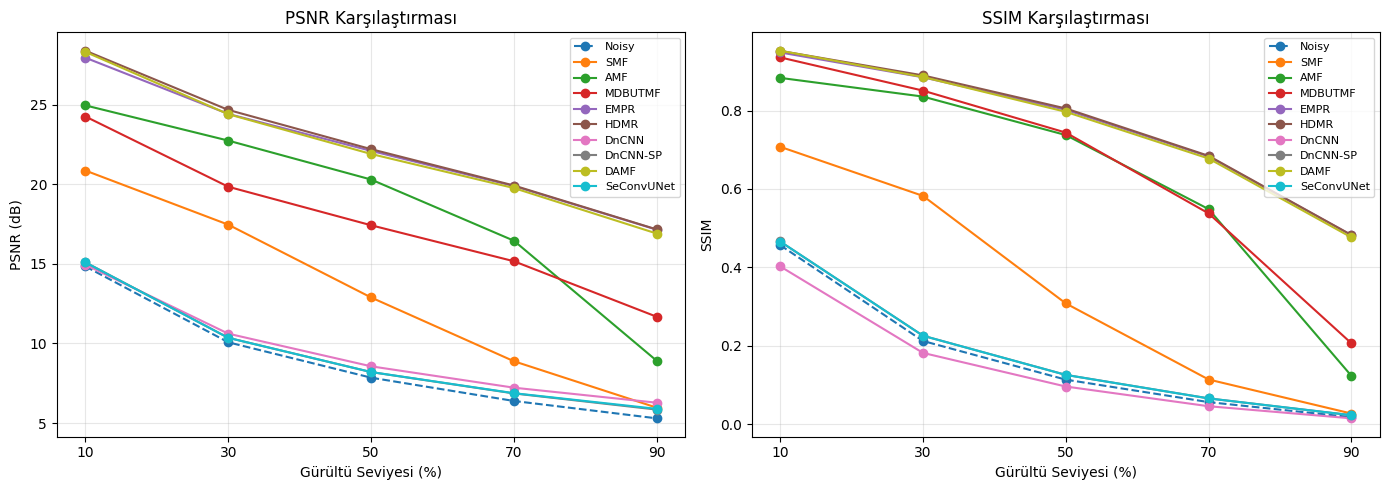

Grafik kaydedildi: psnr_ssim_comparison.pdf/.png


In [12]:
# ─────────────────────────────────────────────────────────
# 10. PSNR ve SSIM GRAFİKLERİ
# ─────────────────────────────────────────────────────────

try:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = cm.tab10.colors

    for idx, (method, _) in enumerate(METHODS.items()):
        psnr_vals = [records[method][lv]['psnr'] if records[method][lv] else float('nan')
                     for lv in NOISE_LEVELS]
        ssim_vals = [records[method][lv]['ssim'] if records[method][lv] else float('nan')
                     for lv in NOISE_LEVELS]
        c = colors[idx % len(colors)]
        ls = '--' if method in ('Noisy',) else '-'
        axes[0].plot(NOISE_LEVELS, psnr_vals, marker='o', label=method, color=c, linestyle=ls)
        axes[1].plot(NOISE_LEVELS, ssim_vals, marker='o', label=method, color=c, linestyle=ls)

    axes[0].set(xlabel='Gürültü Seviyesi (%)', ylabel='PSNR (dB)',
                title='PSNR Karşılaştırması', xticks=NOISE_LEVELS)
    axes[1].set(xlabel='Gürültü Seviyesi (%)', ylabel='SSIM',
                title='SSIM Karşılaştırması', xticks=NOISE_LEVELS)

    for ax in axes:
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('psnr_ssim_comparison.pdf', dpi=150, bbox_inches='tight')
    plt.savefig('psnr_ssim_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Grafik kaydedildi: psnr_ssim_comparison.pdf/.png')
except ImportError:
    print('matplotlib yüklü değil, grafik atlandı.')